# Cosmo-Edu Lab: Galaxy Rotation Curves & Dark Matter 🌌

By observing how fast gas and stars are rotating around the galactic center, we can measure the total gravitational pull. We will then compare this to the gravity generated by the visible matter (stars and gas). The difference will reveal the hidden Dark Matter halo surrounding the galaxy!

### 💡 The Mission:
We will fit the observed rotation curves using the **Burkert Profile** for Dark Matter.


In [ ]:
import os
import glob
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root_scalar
import plotly.express as px

# --- FUNDAMENTAL CONSTANTS ---
# Gravitational constant in units of (kpc * (km/s)^2) / M_sun
G_grav = 4.30091e-6
# Local critical density of the Universe in M_sun / kpc^3
rho_crit_local = 2.775e2

print("Libraries imported and constants defined! Ready for physics.")

Libraries imported and constants defined! Ready for physics.


## Step 1: The Physics of Dark Matter Halos

To model the Dark Matter, we will use the **Burkert Profile**. Unlike other models, the Burkert profile assumes that the dark matter density flattens out near the center of the galaxy (creating a "core") rather than a cuspy profile like NFW.

The mass of Dark Matter enclosed within a radius $r$ is given by:

$$ M_{Burkert}(<r) = 2 \pi \rho_s r_s^3 \left[ \frac{1}{2}\ln\left(1 + \left(\frac{r}{r_s}\right)^2\right) + \ln\left(1+\frac{r}{r_s}\right) - \arctan\left(\frac{r}{r_s}\right) \right] $$

Where:
* **$r_s$** is the scale radius (how spread out the halo is).
* **$\rho_s$** is the central dark matter density.

In [ ]:
def M_burkert_enclosed(r, rho_s, r_s):
    """Calculates the Dark Matter mass enclosed within radius r using the Burkert profile."""
    x = r / r_s
    return 2.0 * np.pi * rho_s * (r_s**3) * (0.5 * np.log(1.0 + x**2) + np.log(1.0 + x) - np.arctan(x))

def observed_rho_from_RC(r, Vobs, Vgas, Vdisk, Vbul, y_disk=0.5, y_bul=0.7):
    """Calculates the observed density profile from the rotation curve."""
    # Splitted Mass-to-Light Ratio: 0.5 for Disk, 0.7 for Bulge
    V_bar_sq = Vgas * np.abs(Vgas) + y_disk * (Vdisk * np.abs(Vdisk)) + y_bul * (Vbul * np.abs(Vbul))
    V_DM_sq = np.maximum(Vobs**2 - V_bar_sq, 0)
    q = r**2 * (V_DM_sq / r)
    dq_dr = np.gradient(q, r)
    rho_DM = (1.0 / (4.0 * np.pi * G_grav * r**2)) * dq_dr
    return rho_DM

## Step 2: The Optimization Algorithm

How do we find the correct $r_s$ and $\rho_s$ for each galaxy? We ask the computer to try thousands of combinations until it finds the one that minimizes the error between our simulated rotation curve and the actual telescope observations. This error is called **Chi-Square ($\chi^2$)**.

For the baryonic velocity we assume a fixed **Mass-to-Light Ratio ($\Upsilon$)** of the stars 0.5 for Disk and 0.7 for Bulge.


In [ ]:
def fit_galaxy_parameters(r, Vobs, errV, Vgas, Vdisk, Vbul):
    """Fits the dark matter profile to the observed rotation curve using a 25x25 grid search."""
    dof = max(1, len(r) - 3)

    # 1. Grid Search limits for rs and rhos (Increased to 25x25 resolution)
    log_rs_grid = np.linspace(np.log10(0.01), np.log10(5000.0), 25)
    log_rhos_grid = np.linspace(np.log10(6.0e4), np.log10(3.02e12), 25)

    verr_safe = np.maximum(errV, 5.0)
    best_chi2 = np.inf
    best_p = (None, None)

    # 2. Initial Grid Search to find a good starting point
    for log_rs in log_rs_grid:
        rs = 10**log_rs
        for log_rhos in log_rhos_grid:
            rho_s = 10**log_rhos
            x_arr = r / rs
            M_dm_arr = 2.0 * np.pi * rho_s * (rs**3) * (0.5 * np.log(1.0 + x_arr**2) + np.log(1.0 + x_arr) - np.arctan(x_arr))
            V_dm_sq_arr = (G_grav * M_dm_arr) / r

            # Split Baryonic velocity calculation: Disk 0.5, Bulge 0.7
            V_bar_sq = Vgas * np.abs(Vgas) + 0.5 * (Vdisk * np.abs(Vdisk)) + 0.7 * (Vbul * np.abs(Vbul))
            V_tot = np.sqrt(np.maximum(V_bar_sq + V_dm_sq_arr, 0))

            chi2 = np.sum(((Vobs - V_tot) / verr_safe)**2) / dof
            if chi2 < best_chi2:
                best_chi2 = chi2
                best_p = (log_rs, log_rhos)

    # 3. SLSQP Optimization function
    def objective(params):
        log_rs, log_rhos = params
        rs = 10**log_rs
        rho_s = 10**log_rhos

        # Split Baryonic velocity calculation: Disk 0.5, Bulge 0.7
        V_bar_sq_opt = Vgas * np.abs(Vgas) + 0.5 * (Vdisk * np.abs(Vdisk)) + 0.7 * (Vbul * np.abs(Vbul))
        x_opt = r / rs
        M_dm_opt = 2.0 * np.pi * rho_s * (rs**3) * (0.5 * np.log(1.0 + x_opt**2) + np.log(1.0 + x_opt) - np.arctan(x_opt))
        V_tot_opt = np.sqrt(np.maximum(V_bar_sq_opt + (G_grav * M_dm_opt) / r, 0))
        return np.sum(((Vobs - V_tot_opt) / verr_safe)**2) / dof

    limiti = [
        (np.log10(0.01), np.log10(5000.0)),
        (np.log10(6.0e4), np.log10(3.02e12))
    ]

    best_p_clipped = (
        np.clip(best_p[0], limiti[0][0], limiti[0][1]),
        np.clip(best_p[1], limiti[1][0], limiti[1][1])
    )

    res = minimize(objective, best_p_clipped, method='SLSQP', bounds=limiti, tol=1e-8)

    log_rs_fin, log_rhos_fin = res.x
    y_disk_fin = 0.5
    y_bul_fin = 0.7
    r_s_fin = 10**log_rs_fin
    rho_s_fin = 10**log_rhos_fin

    # Calculate M200 using root finding
    def find_c200(c):
        term = 0.5 * np.log(1.0 + c**2) + np.log(1.0 + c) - np.arctan(c)
        rho_s_teorica = (400.0 / 3.0) * rho_crit_local * (c**3) / term
        return rho_s_teorica - rho_s_fin

    try:
        res_c = root_scalar(find_c200, bracket=[1e-2, 1e5], method='brentq')
        c200_calc = res_c.root
        r200_calc = c200_calc * r_s_fin
        M200_fin = (800.0 / 3.0) * np.pi * rho_crit_local * (r200_calc**3)
    except ValueError:
        M200_fin = 0.0

    if res.success and res.fun < best_chi2:
        return res.fun, rho_s_fin, r_s_fin, y_disk_fin, y_bul_fin, M200_fin

    return best_chi2, rho_s_fin, r_s_fin, y_disk_fin, y_bul_fin, M200_fin

## Step 3: Running the Analysis Pipeline

It's time to process our data! Make sure you have uploaded the `Table.txt` file and the dataset `Rotmod_LTG` folder into your Colab environment.

The pipeline will:
1. Cross-reference the galaxies to remove non-ideal candidates (e.g., disk-halo degeneracy galaxies or those with poor data quality).
2. Fit the rotation curve for every single valid galaxy.
3. Plot the final rotation curve and output the results.

✅ SUCCESS: Found 175 Quality flags in '/content/drive/MyDrive/Cosmo-Edu-Lab/Table.txt'!
----------------------------------------------------------------------------------------------------------------------
Galaxy          | Q   | Chi2 Min | rho_s     | r_s    | Ups D/B | M_bar_edg | M_DM_edg  | M_tot_edg | % DM  
----------------------------------------------------------------------------------------------------------------------
ESO563-G021_rotmod | 1   | 7.80     | 7.63e+07  | 9.11   | 0.5/0.7 | 2.10e+11  | 7.02e+11  | 9.12e+11  |  76.9%


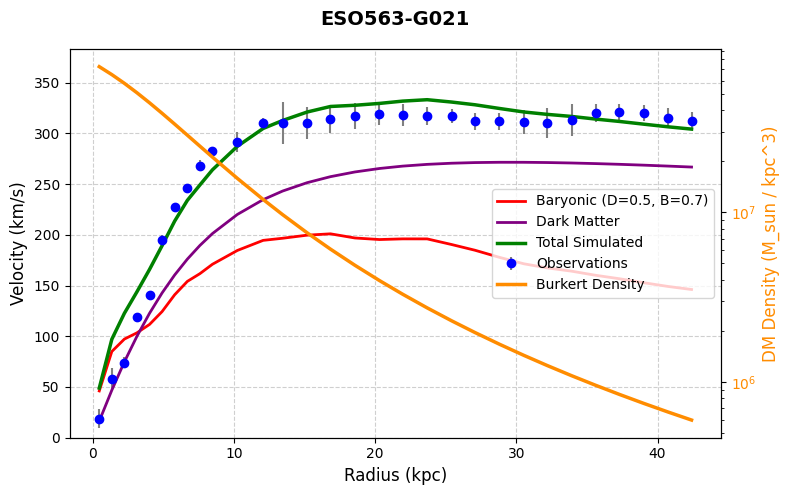

IC4202_rotmod   | 1   | 21.50    | 5.06e+07  | 7.69   | 0.5/0.7 | 1.32e+11  | 2.09e+11  | 3.41e+11  |  61.3%


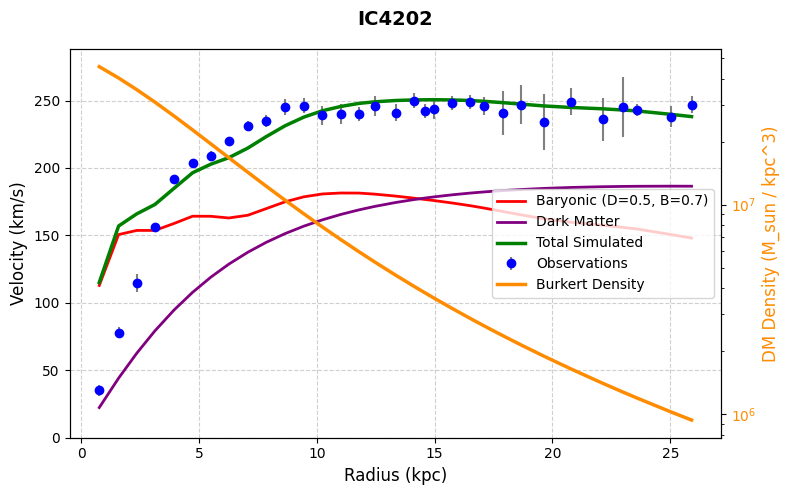

NGC0801_rotmod  | 1   | 10.76    | 4.86e+07  | 6.81   | 0.5/0.7 | 2.36e+11  | 2.90e+11  | 5.26e+11  |  55.1%


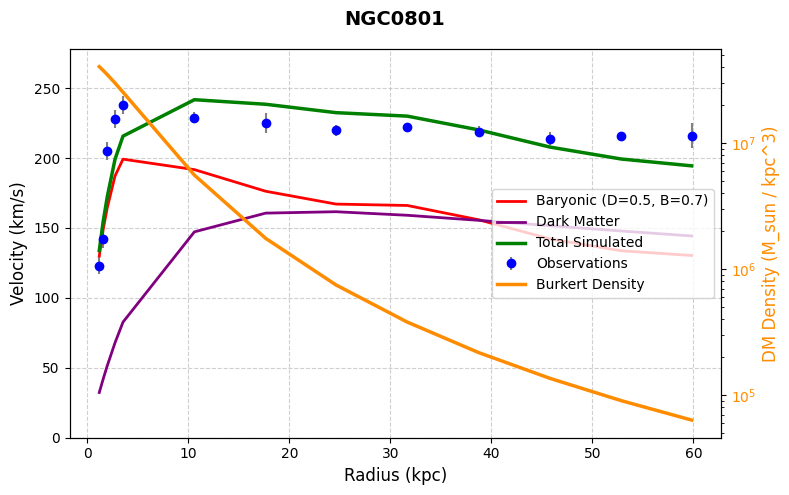

NGC0891_rotmod  | 1   | 12.24    | 1.10e+07  | 18.98  | 0.5/0.7 | 8.76e+10  | 9.73e+10  | 1.85e+11  |  52.6%


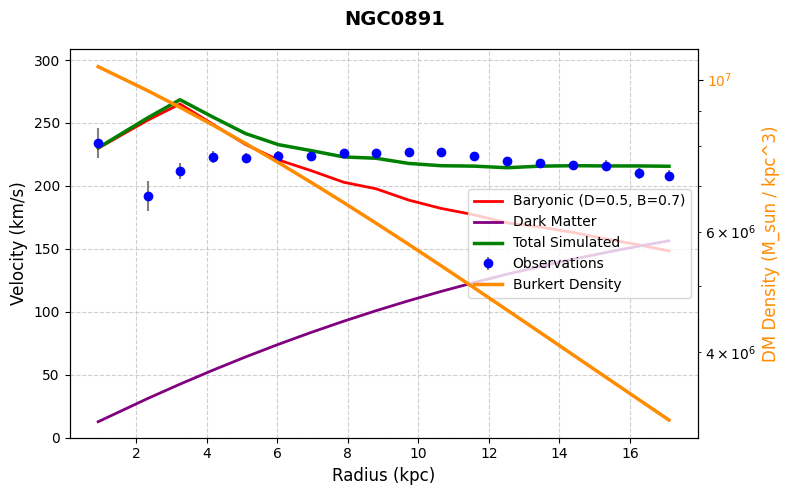

NGC1090_rotmod  | 1   | 1.12     | 3.90e+07  | 6.14   | 0.5/0.7 | 5.87e+10  | 1.14e+11  | 1.73e+11  |  66.1%


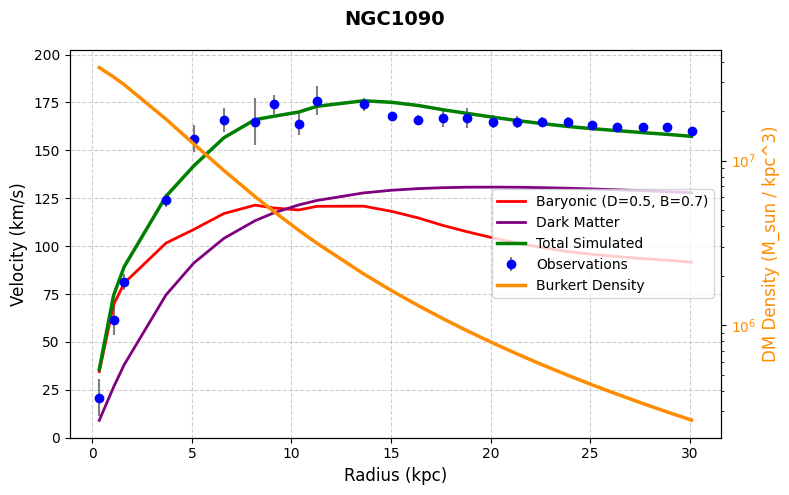

NGC2403_rotmod  | 1   | 1.91     | 6.75e+07  | 4.22   | 0.5/0.7 | 1.28e+10  | 6.47e+10  | 7.76e+10  |  83.4%


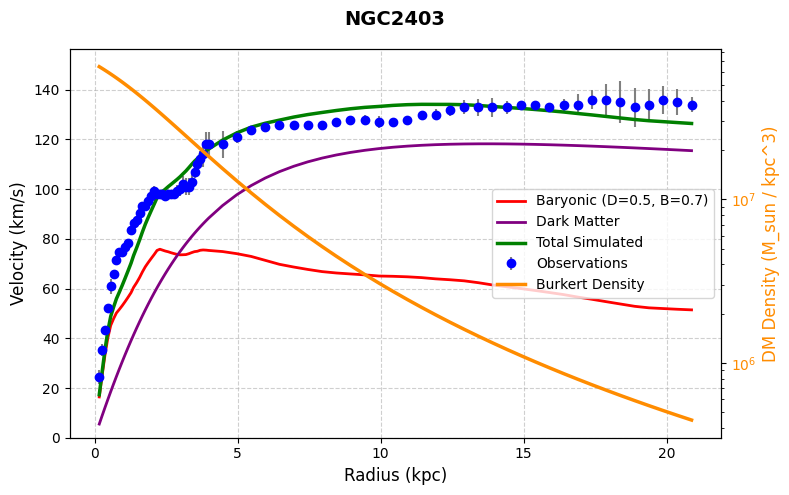

NGC2841_rotmod  | 1   | 6.01     | 1.71e+08  | 6.07   | 0.5/0.7 | 1.74e+11  | 7.97e+11  | 9.71e+11  |  82.0%


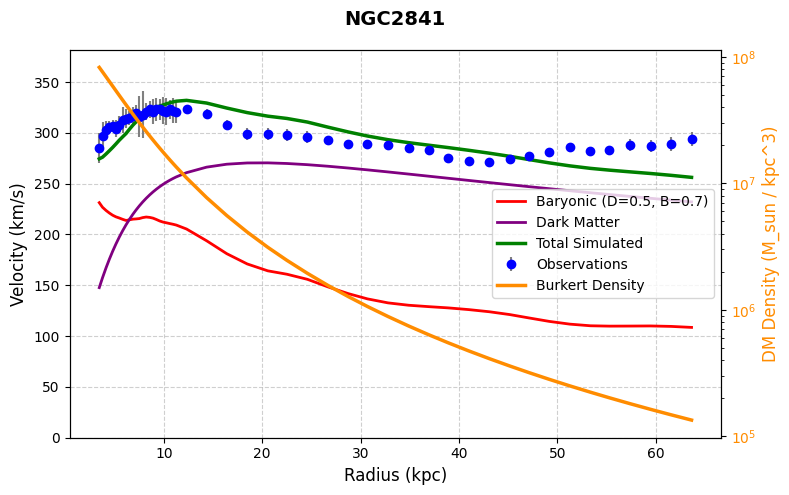

NGC2903_rotmod  | 1   | 9.02     | 3.84e+07  | 7.34   | 0.5/0.7 | 4.70e+10  | 1.40e+11  | 1.87e+11  |  74.8%


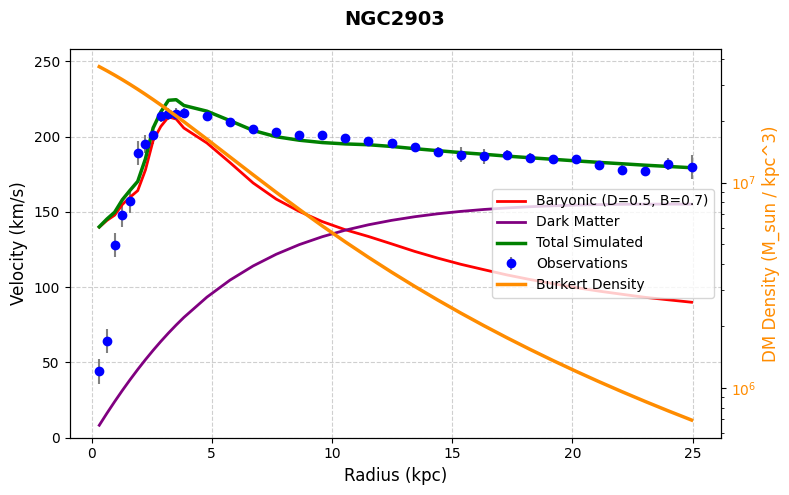

NGC2998_rotmod  | 1   | 5.63     | 3.52e+07  | 8.44   | 0.5/0.7 | 1.24e+11  | 2.73e+11  | 3.97e+11  |  68.8%


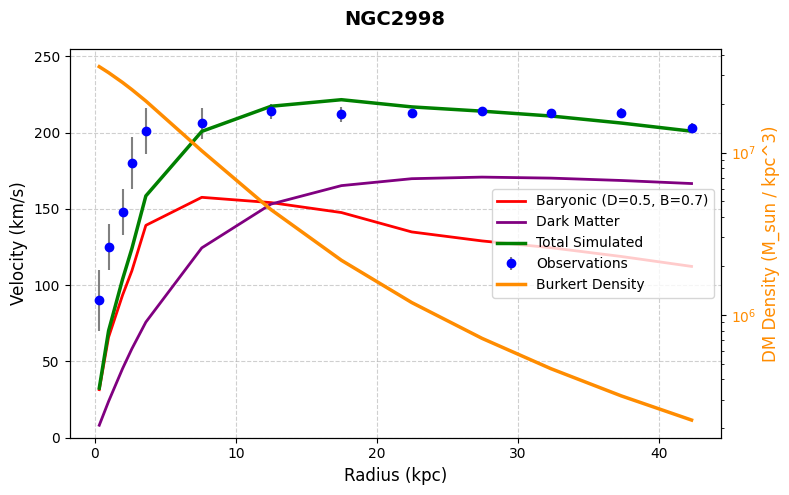

NGC3198_rotmod  | 1   | 0.54     | 3.68e+07  | 6.49   | 0.5/0.7 | 4.29e+10  | 1.62e+11  | 2.05e+11  |  79.0%


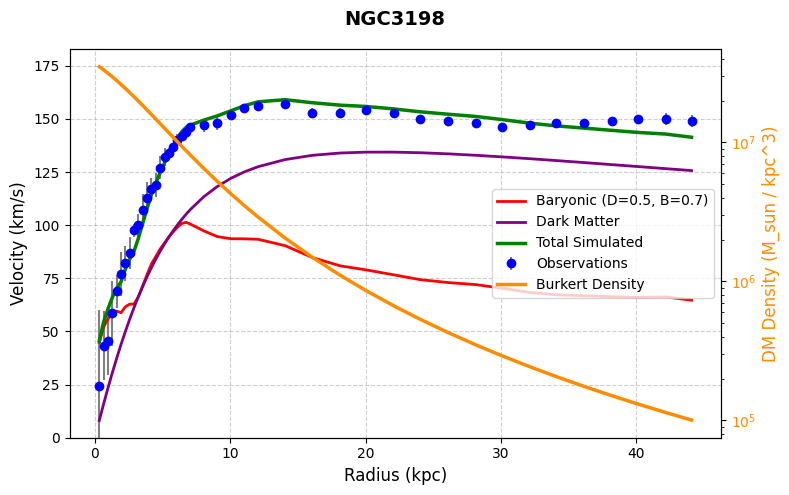

NGC3521_rotmod  | 1   | 0.81     | 7.19e+07  | 5.67   | 0.5/0.7 | 5.22e+10  | 1.11e+11  | 1.63e+11  |  68.0%


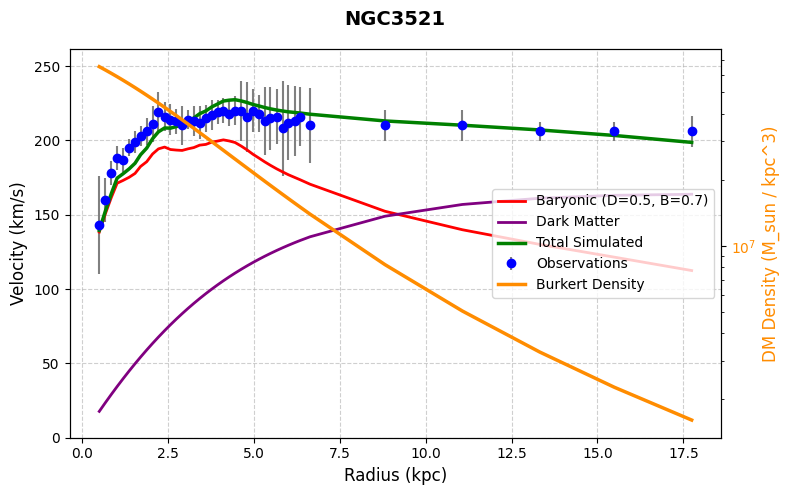

NGC3893_rotmod  | 1   | 0.40     | 6.94e+07  | 5.13   | 0.5/0.7 | 4.03e+10  | 9.35e+10  | 1.34e+11  |  69.9%


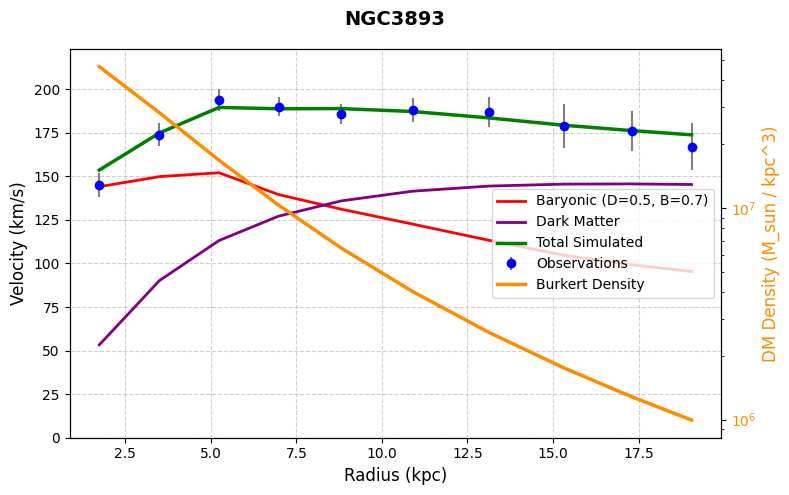

NGC3917_rotmod  | 1   | 0.78     | 5.00e+07  | 4.79   | 0.5/0.7 | 1.70e+10  | 4.60e+10  | 6.30e+10  |  73.0%


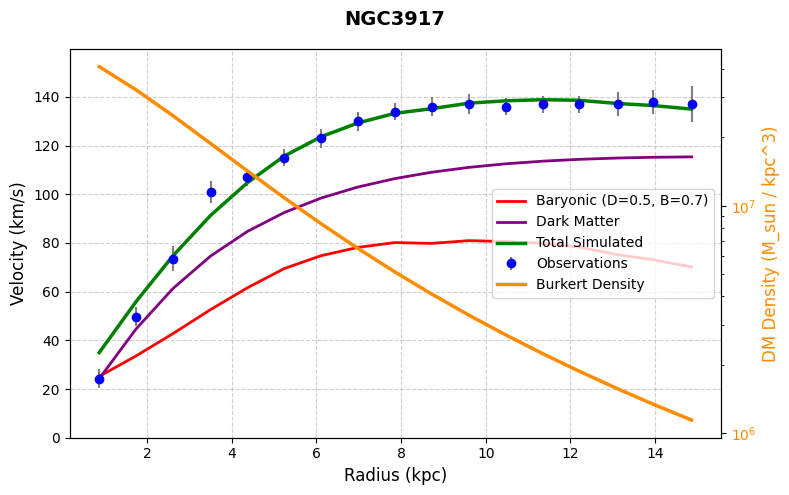

NGC3953_rotmod  | 1   | 0.22     | 1.53e+08  | 3.40   | 0.5/0.7 | 9.24e+10  | 7.26e+10  | 1.65e+11  |  44.0%


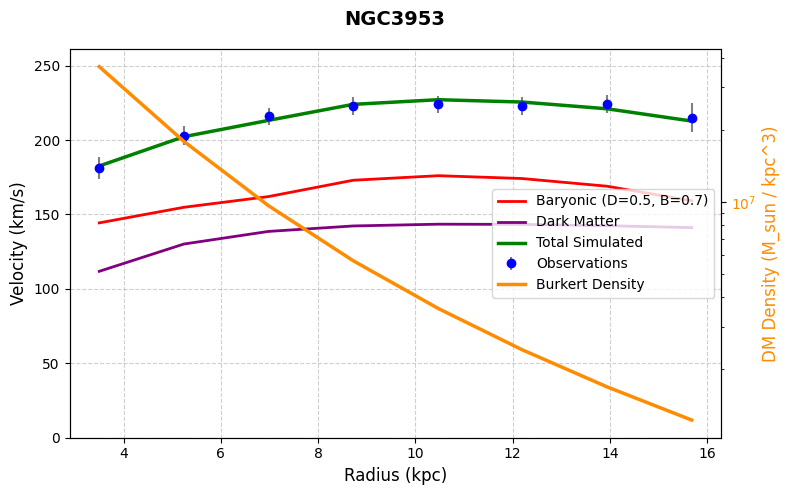

NGC3992_rotmod  | 1   | 0.83     | 8.40e+07  | 6.80   | 0.5/0.7 | 1.44e+11  | 4.23e+11  | 5.67e+11  |  74.6%


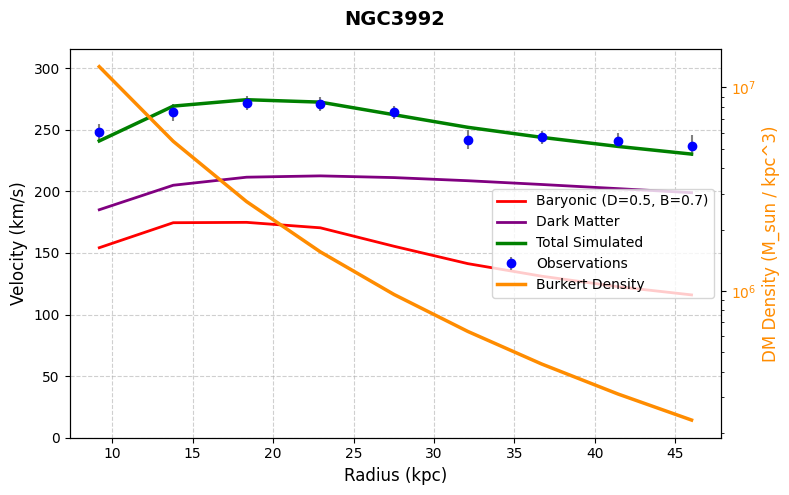

NGC4088_rotmod  | 1   | 1.11     | 1.81e+06  | 2116.34 | 0.5/0.7 | 7.06e+10  | 7.45e+10  | 1.45e+11  |  51.3%


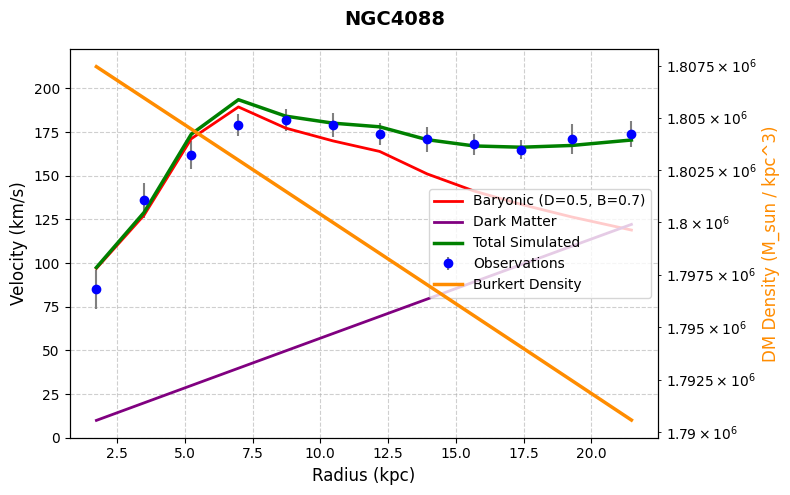

NGC4100_rotmod  | 1   | 0.61     | 1.29e+08  | 3.73   | 0.5/0.7 | 3.73e+10  | 9.98e+10  | 1.37e+11  |  72.8%


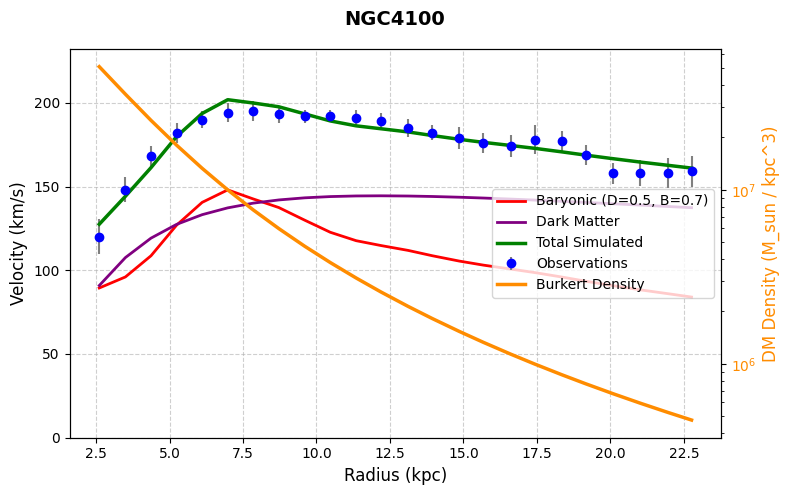

NGC4157_rotmod  | 1   | 0.40     | 8.65e+06  | 16.19  | 0.5/0.7 | 6.77e+10  | 1.62e+11  | 2.30e+11  |  70.6%


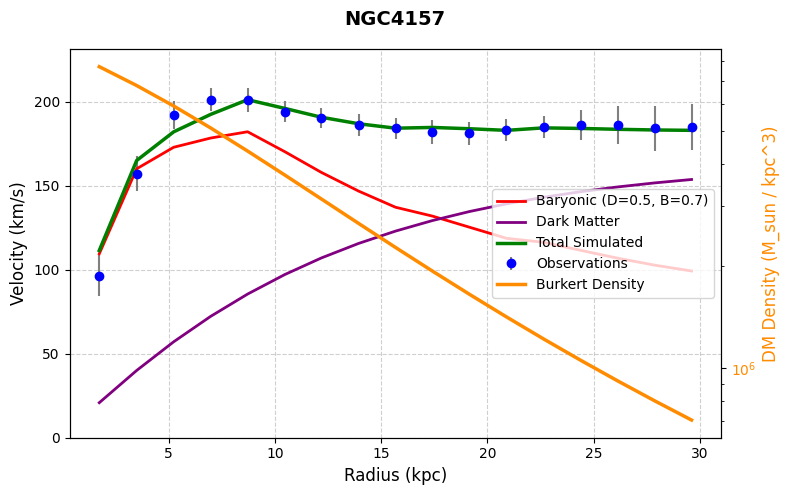

NGC4183_rotmod  | 1   | 0.40     | 6.48e+07  | 3.44   | 0.5/0.7 | 1.22e+10  | 3.94e+10  | 5.16e+10  |  76.4%


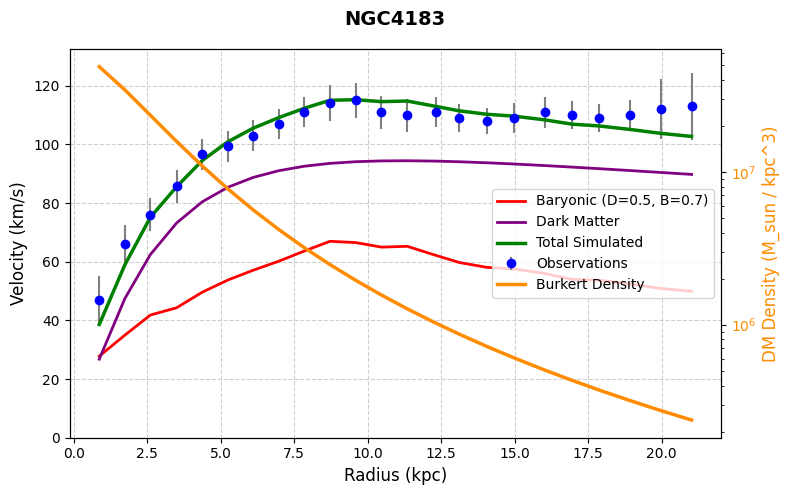

NGC4217_rotmod  | 1   | 35.77    | 3.76e+06  | 606.01 | 0.5/0.7 | 6.18e+10  | 7.21e+10  | 1.34e+11  |  53.9%


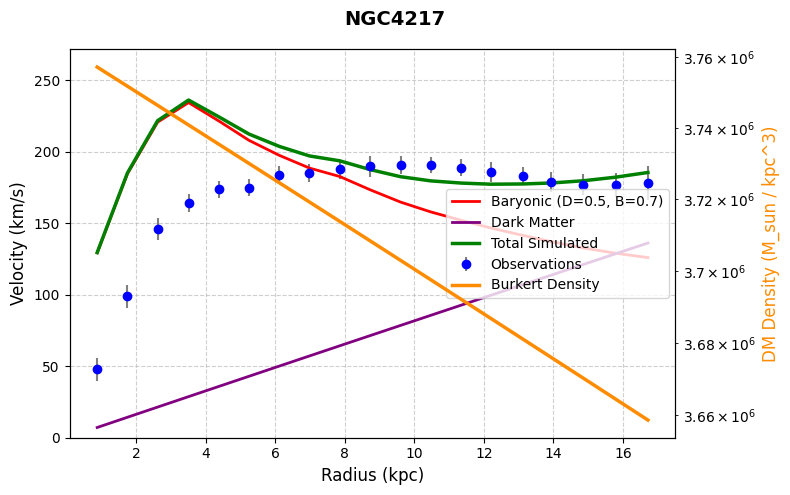

NGC4559_rotmod  | 1   | 0.23     | 1.80e+07  | 6.97   | 0.5/0.7 | 2.34e+10  | 4.95e+10  | 7.29e+10  |  67.9%


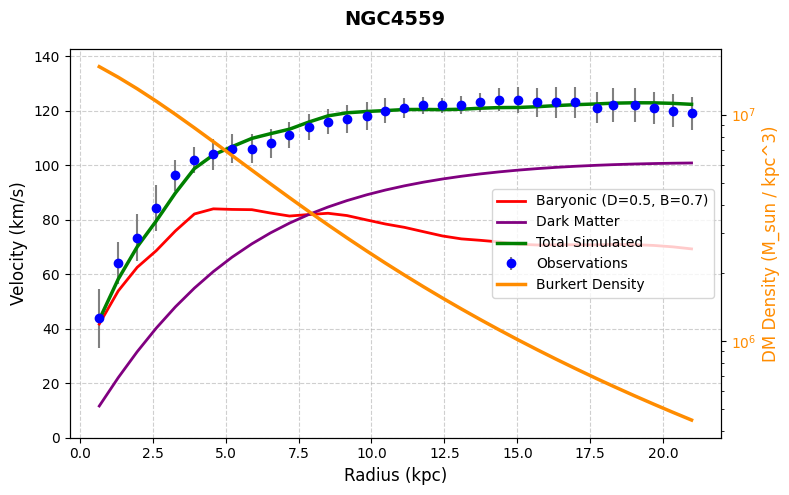

NGC5005_rotmod  | 1   | 0.45     | 2.29e+07  | 18.01  | 0.5/0.7 | 1.08e+11  | 8.07e+10  | 1.89e+11  |  42.7%


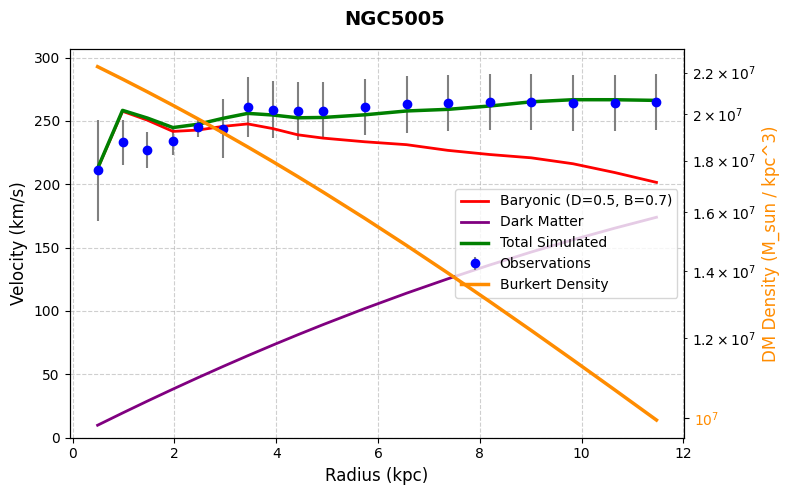

NGC5033_rotmod  | 1   | 1.64     | 4.82e+07  | 7.50   | 0.5/0.7 | 8.13e+10  | 2.98e+11  | 3.79e+11  |  78.6%


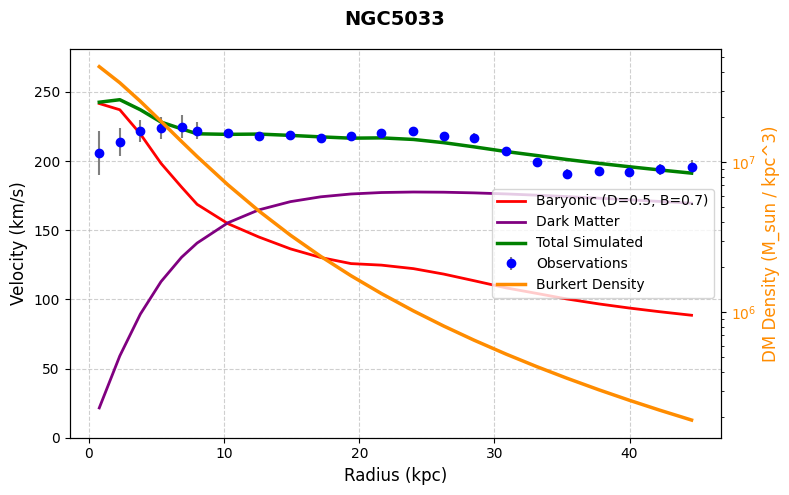

NGC5055_rotmod  | 1   | 0.97     | 8.82e+06  | 14.91  | 0.5/0.7 | 9.80e+10  | 2.88e+11  | 3.86e+11  |  74.6%


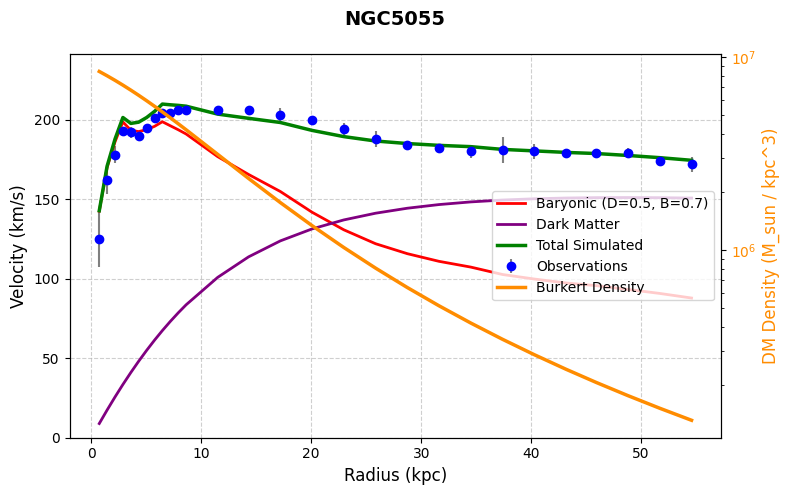

NGC5371_rotmod  | 1   | 8.51     | 1.11e+08  | 3.96   | 0.5/0.7 | 2.00e+11  | 1.52e+11  | 3.52e+11  |  43.1%


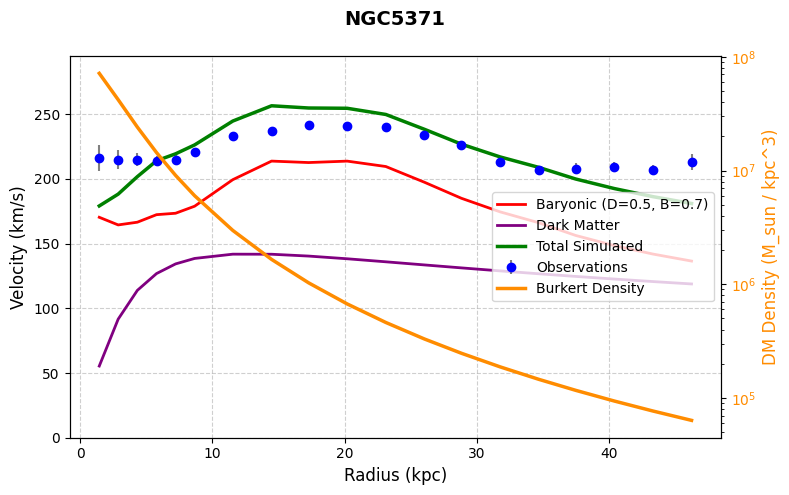

NGC5907_rotmod  | 1   | 5.58     | 8.05e+07  | 6.05   | 0.5/0.7 | 1.39e+11  | 3.25e+11  | 4.64e+11  |  70.0%


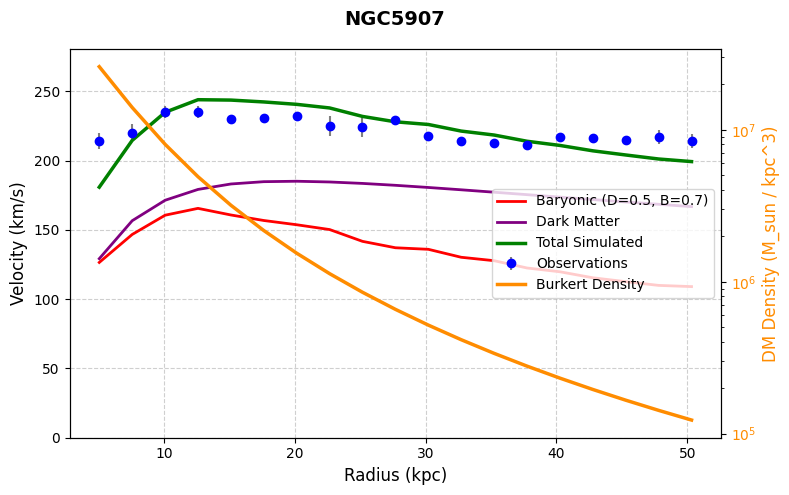

NGC5985_rotmod  | 1   | 2.31     | 3.14e+08  | 4.23   | 0.5/0.7 | 1.57e+11  | 4.31e+11  | 5.88e+11  |  73.4%


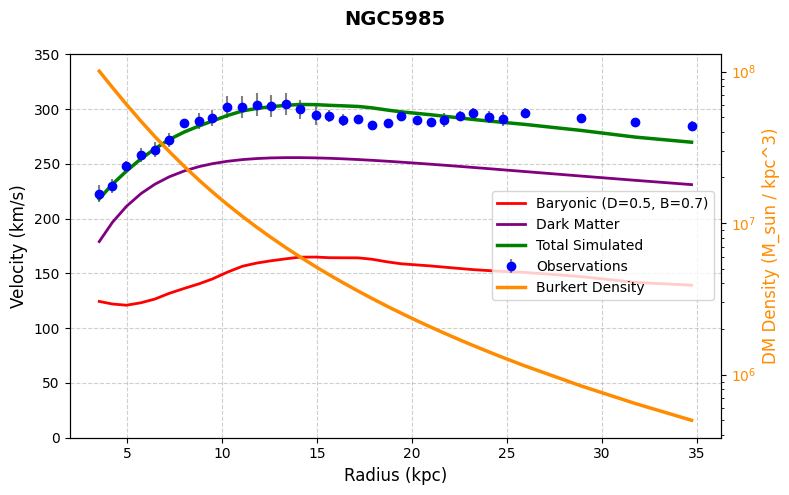

NGC6195_rotmod  | 1   | 1.57     | 4.50e+06  | 27.92  | 0.5/0.7 | 2.56e+11  | 2.55e+11  | 5.11e+11  |  49.9%


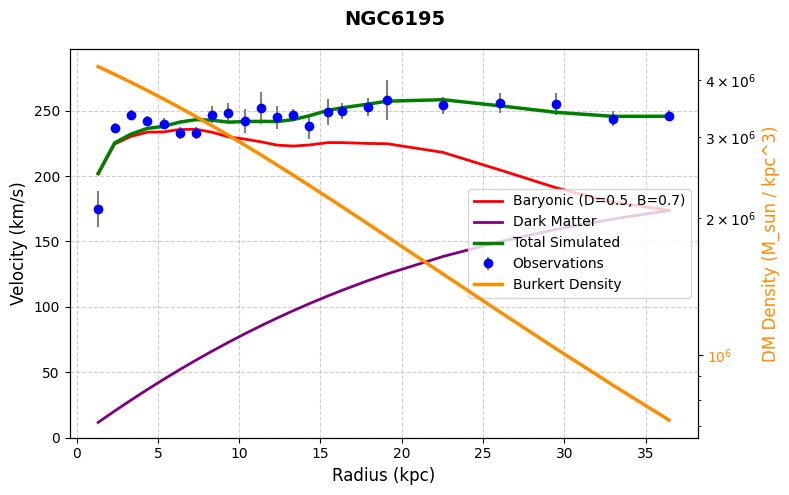

NGC6503_rotmod  | 1   | 0.56     | 4.92e+07  | 4.40   | 0.5/0.7 | 1.00e+10  | 5.66e+10  | 6.67e+10  |  84.9%


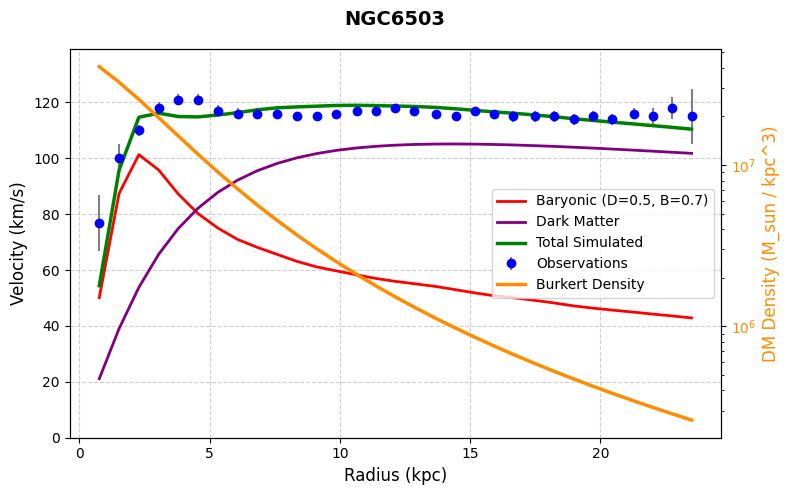

NGC6674_rotmod  | 1   | 9.23     | 7.55e+07  | 7.66   | 0.5/0.7 | 1.48e+11  | 6.67e+11  | 8.15e+11  |  81.8%


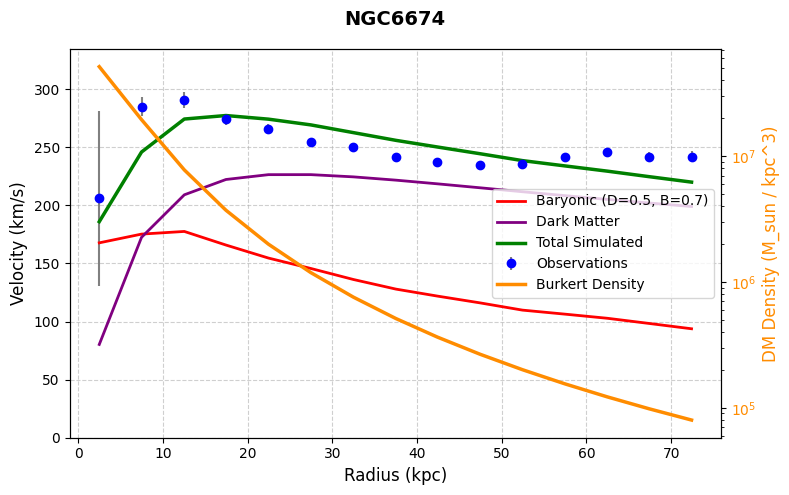

NGC6946_rotmod  | 1   | 0.91     | 3.11e+07  | 6.53   | 0.5/0.7 | 4.22e+10  | 7.31e+10  | 1.15e+11  |  63.4%


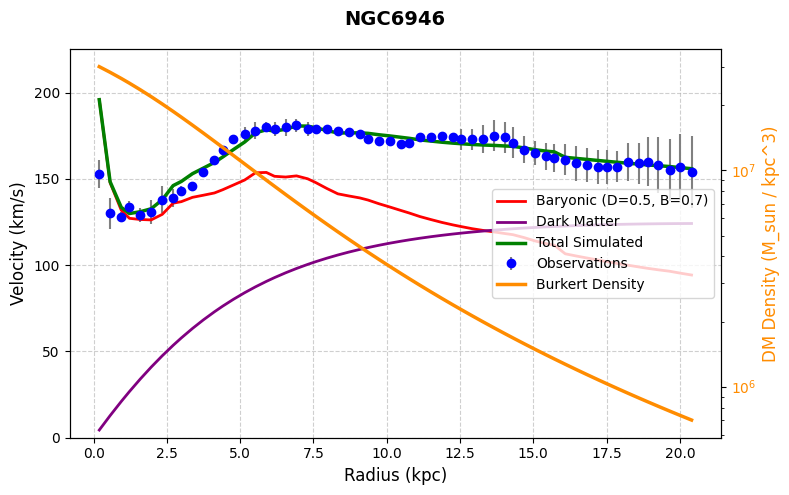

NGC7331_rotmod  | 1   | 4.07     | 6.38e+06  | 26.12  | 0.5/0.7 | 1.55e+11  | 3.30e+11  | 4.85e+11  |  68.0%


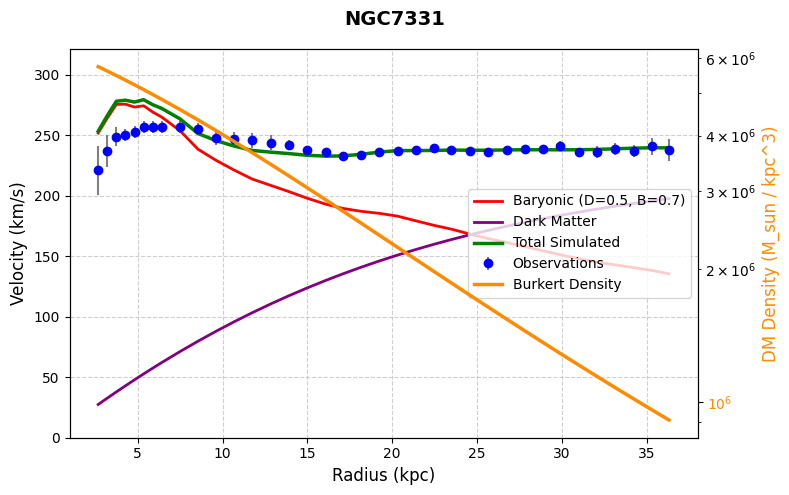

NGC7814_rotmod  | 1   | 0.61     | 7.24e+07  | 6.25   | 0.5/0.7 | 5.13e+10  | 1.49e+11  | 2.01e+11  |  74.4%


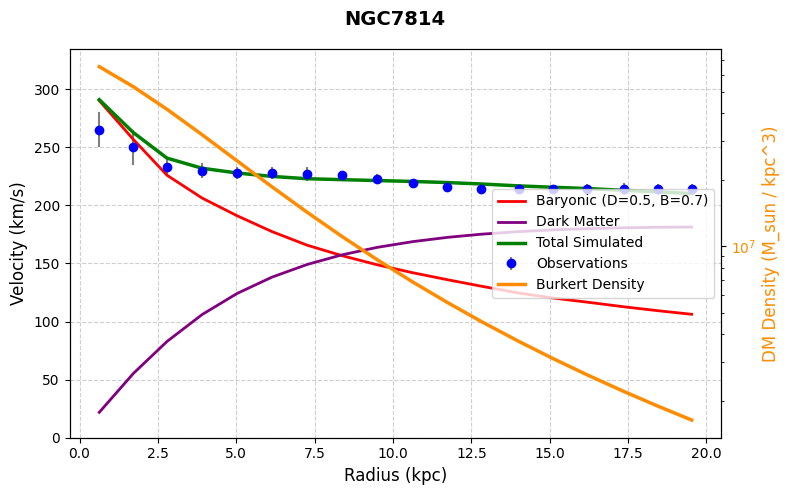

UGC00128_rotmod | 1   | 1.13     | 1.92e+07  | 8.16   | 0.5/0.7 | 2.15e+10  | 1.64e+11  | 1.85e+11  |  88.4%


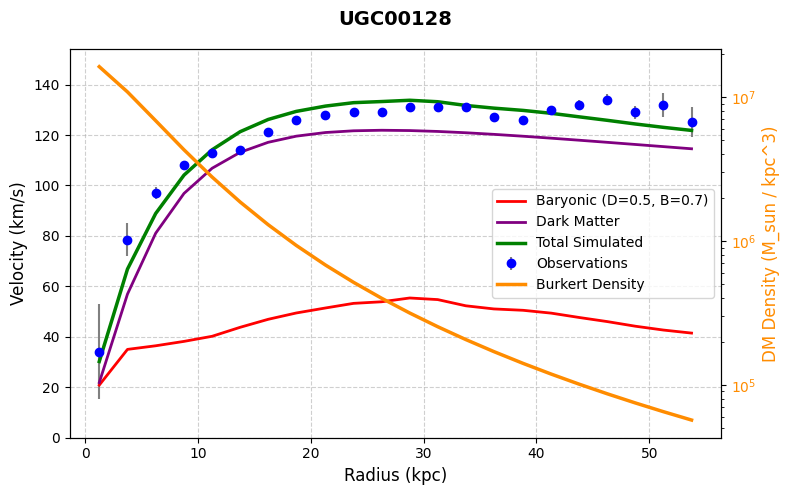

UGC02487_rotmod | 1   | 2.60     | 1.02e+08  | 9.15   | 0.5/0.7 | 3.11e+11  | 1.48e+12  | 1.79e+12  |  82.6%


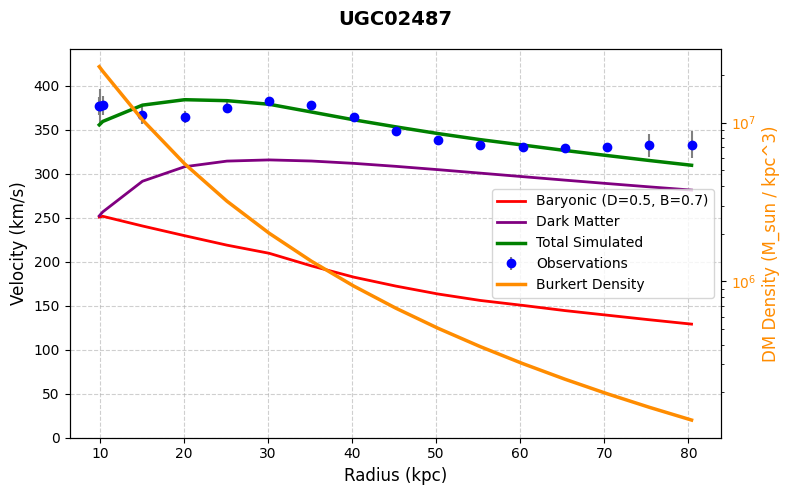

UGC03205_rotmod | 1   | 4.83     | 1.68e+08  | 4.09   | 0.5/0.7 | 7.92e+10  | 2.31e+11  | 3.10e+11  |  74.4%


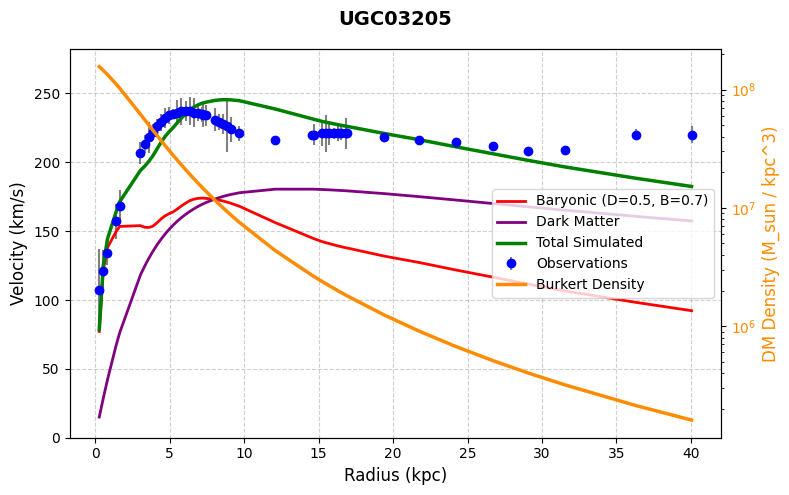

UGC03546_rotmod | 1   | 1.80     | 2.28e+07  | 9.81   | 0.5/0.7 | 6.27e+10  | 1.73e+11  | 2.35e+11  |  73.4%


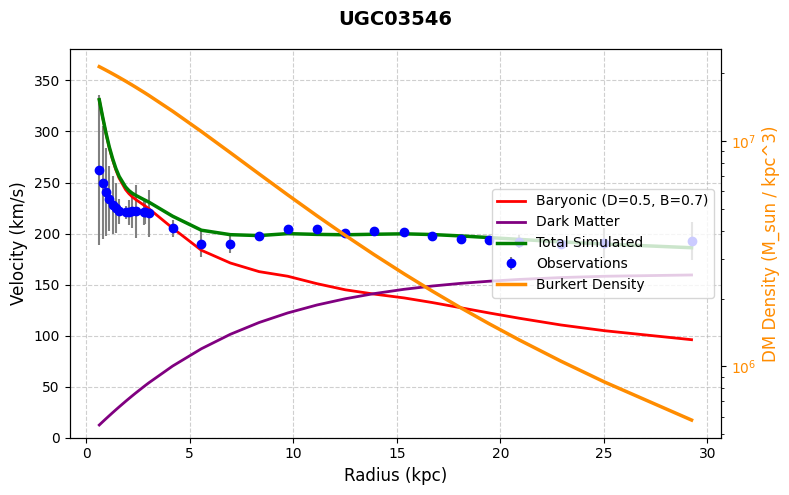

UGC04325_rotmod | 1   | 0.18     | 3.10e+08  | 1.36   | 0.5/0.7 | 2.46e+09  | 8.52e+09  | 1.10e+10  |  77.6%


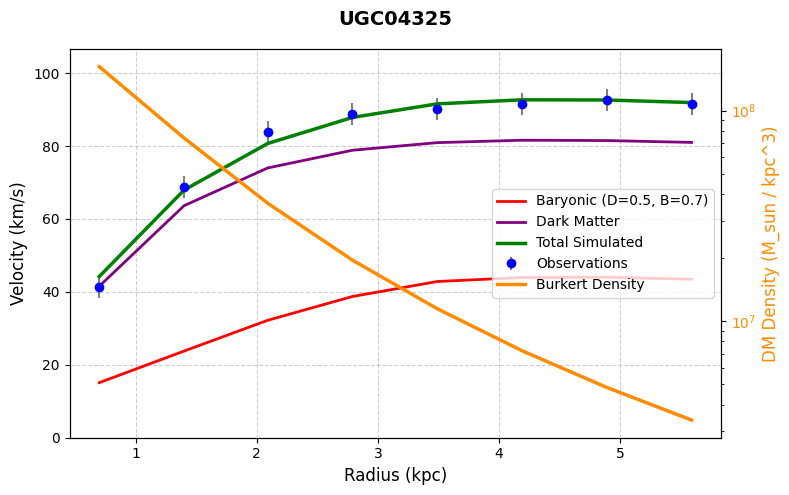

UGC05721_rotmod | 1   | 0.36     | 4.79e+08  | 1.02   | 0.5/0.7 | 1.22e+09  | 8.00e+09  | 9.22e+09  |  86.8%


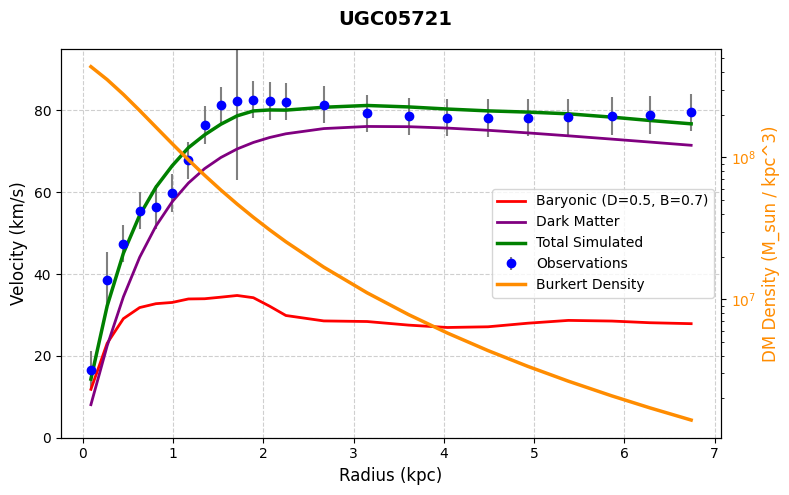

UGC06446_rotmod | 1   | 0.37     | 1.27e+08  | 1.92   | 0.5/0.7 | 3.16e+09  | 1.21e+10  | 1.52e+10  |  79.3%


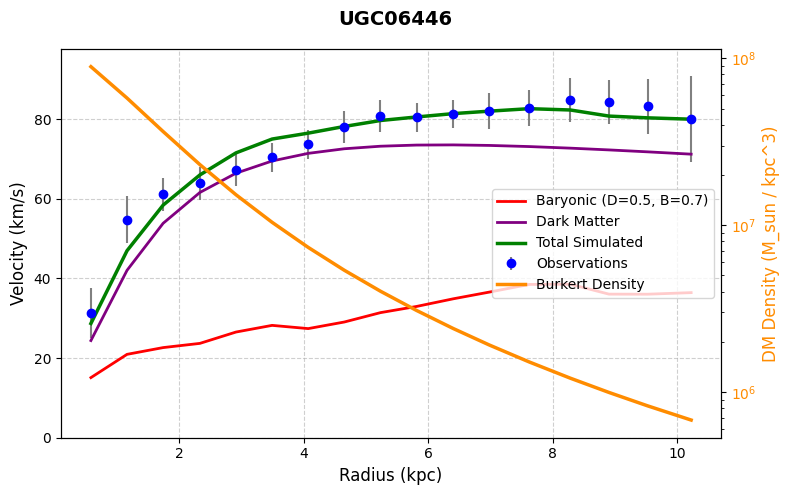

UGC06614_rotmod | 1   | 0.23     | 4.28e+06  | 27.75  | 0.5/0.7 | 1.33e+11  | 5.56e+11  | 6.89e+11  |  80.7%


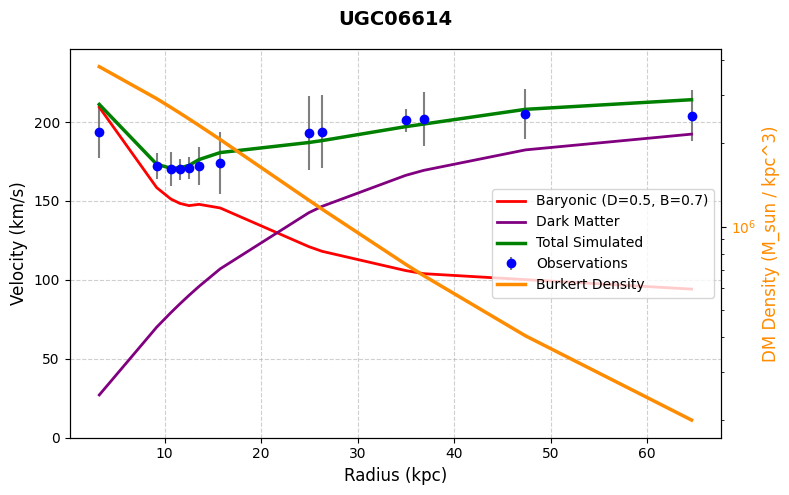

UGC06786_rotmod | 1   | 1.19     | 1.07e+08  | 5.69   | 0.5/0.7 | 4.88e+10  | 2.91e+11  | 3.40e+11  |  85.6%


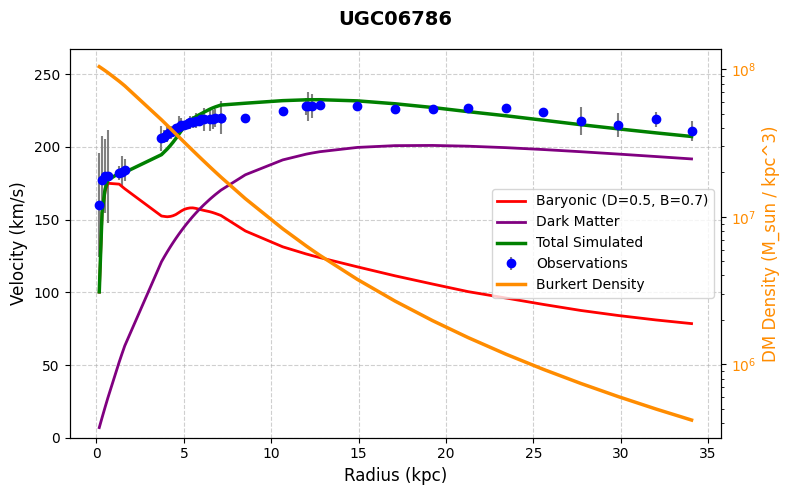

UGC06983_rotmod | 1   | 0.39     | 7.98e+07  | 3.18   | 0.5/0.7 | 8.77e+09  | 3.26e+10  | 4.14e+10  |  78.8%


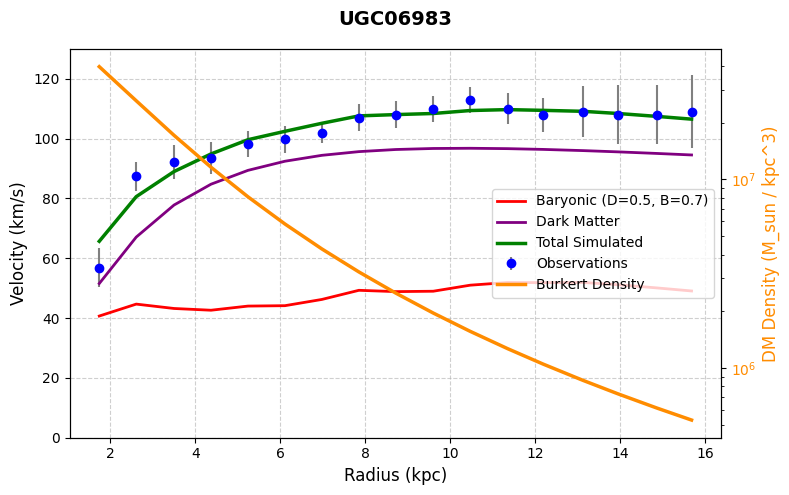

UGC08490_rotmod | 1   | 0.37     | 2.45e+08  | 1.40   | 0.5/0.7 | 1.72e+09  | 1.13e+10  | 1.30e+10  |  86.8%


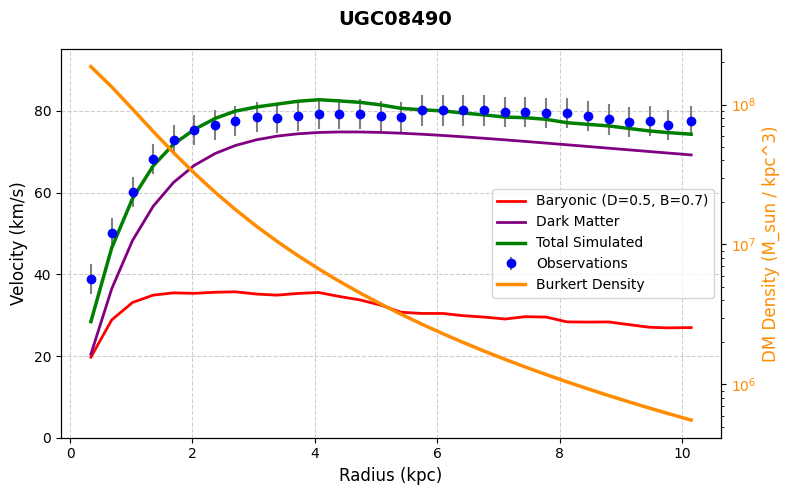

UGC09133_rotmod | 1   | 2.33     | 3.14e+07  | 11.13  | 0.5/0.7 | 2.26e+11  | 8.66e+11  | 1.09e+12  |  79.3%


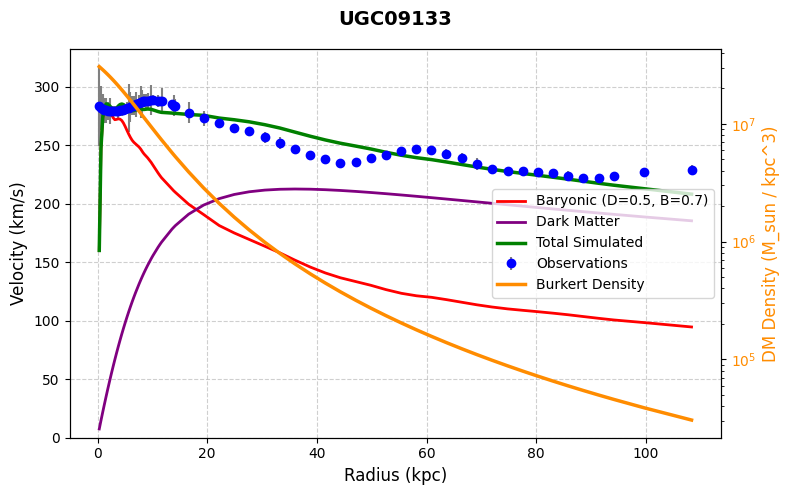

UGC11455_rotmod | 1   | 2.90     | 1.98e+07  | 13.74  | 0.5/0.7 | 2.29e+11  | 4.25e+11  | 6.54e+11  |  64.9%


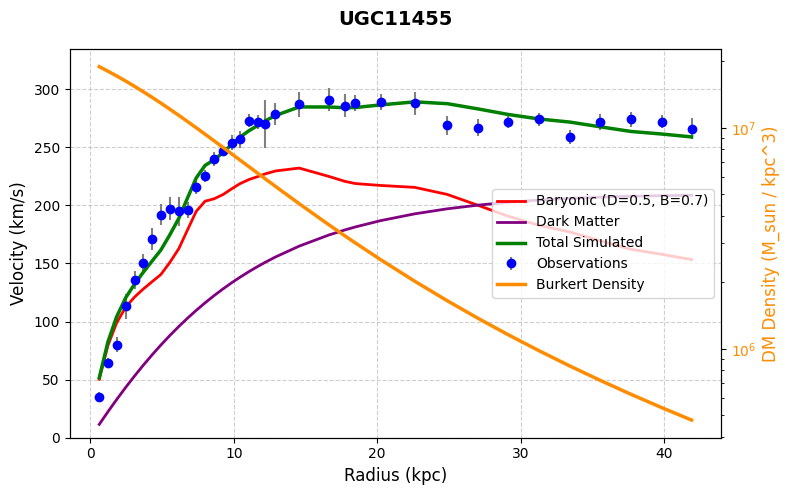

UGC11914_rotmod | 1   | 3.52     | 1.91e+09  | 1.22   | 0.5/0.7 | 8.44e+10  | 6.24e+10  | 1.47e+11  |  42.5%


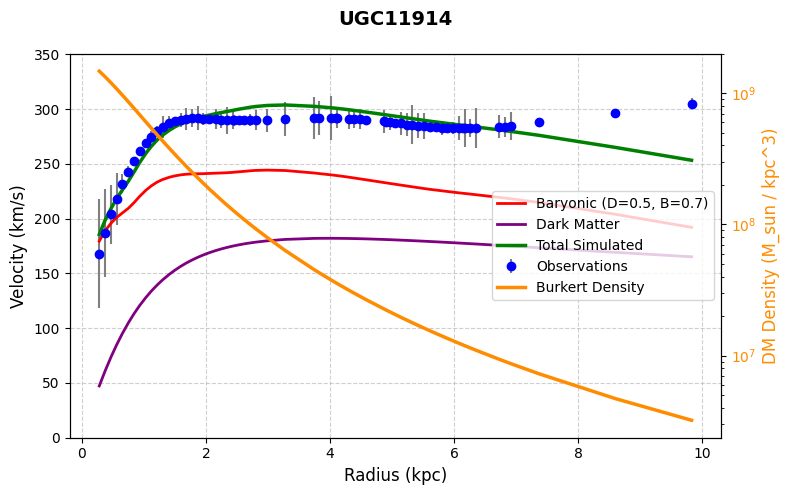

----------------------------------------------------------------------------------------------------------------------
Analysis complete. Results and parameters saved to CSV.


In [ ]:

input_folder = "/content/drive/MyDrive/Cosmo-Edu-Lab/Rotmod_LTG"
output_folder = "lab_results"
export_file = "galaxy_split_results.csv"
os.makedirs(output_folder, exist_ok=True)

q_dict = {}
mrt_file = "/content/drive/MyDrive/Cosmo-Edu-Lab/Table.txt"

if os.path.exists(mrt_file):
    with open(mrt_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            sline = line.strip()
            if not sline or sline.startswith('-') or sline.startswith('=') or "Byte" in sline or "Note" in sline:
                continue
            parts = sline.split()
            if len(parts) >= 18 and parts[0].upper() != "GALAXY":
                name = parts[0].strip().upper()
                inc_str = parts[5].strip()
                vflat_str = parts[15].strip()
                q_str = parts[17].strip()
                if q_str.isdigit():
                    q_dict[name] = {"Q": int(q_str), "Inc": float(inc_str) if inc_str else 0.0, "Vflat": float(vflat_str) if vflat_str else 0.0}
    print(f"✅ SUCCESS: Found {len(q_dict)} Quality flags in '{mrt_file}'!")
else:
    print(f"❌ CRITICAL ERROR: File '{mrt_file}' not found! Please upload it.")

all_files = glob.glob(os.path.join(input_folder, "*"))
files = [f for f in all_files]

print("-" * 118)
print(f"{'Galaxy':<15} | {'Q':<3} | {'Chi2 Min':<8} | {'rho_s':<9} | {'r_s':<6} | {'Ups D/B':<7} | {'M_bar_edg':<9} | {'M_DM_edg':<9} | {'M_tot_edg':<9} | {'% DM':<6}")
print("-" * 118)

results_data = []

for file in sorted(files):
    gal_name = os.path.splitext(os.path.basename(file))[0]
    gal_name_clean = gal_name.replace("_rotmod", "").strip().upper()
    gal_info = q_dict.get(gal_name_clean, {"Q": "?", "Inc": 0.0})
    Q_val, Inc_val, Vflat_val = gal_info["Q"], gal_info["Inc"], gal_info.get("Vflat", 0.0)

    # --- FILTERS ---
    if Q_val in [2, 3]: continue
    if isinstance(Inc_val, float) and Inc_val < 30.0: continue
    if isinstance(Vflat_val, float) and Vflat_val == 0.0: continue

    try:
        with open(file, 'r') as f: lines = f.readlines()

        header_line, data_lines = None, []
        for line in lines:
            sline = line.strip()
            if not sline: continue
            if sline.startswith('#'):
                if 'Rad' in sline and 'Vobs' in sline: header_line = sline.replace('#', '').strip() + '\n'
            else:
                data_lines.append(line)

        if not header_line or not data_lines: continue

        full_data_str = header_line + "".join(data_lines)
        df = pd.read_csv(io.StringIO(full_data_str), sep=r'\s+')
        if 'Rad' not in df.columns: continue

        r = df['Rad'].values.astype(float)
        Vobs = df['Vobs'].values.astype(float)
        errV = df['errV'].values.astype(float) if 'errV' in df.columns else np.ones_like(Vobs) * 5.0
        Vgas = df['Vgas'].values.astype(float) if 'Vgas' in df.columns else np.zeros_like(Vobs)
        Vdisk = df['Vdisk'].values.astype(float) if 'Vdisk' in df.columns else np.zeros_like(Vobs)
        Vbul = df['Vbul'].values.astype(float) if 'Vbul' in df.columns else np.zeros_like(Vobs)

        R_max = r[-1]
        mid_mask, out_mask = (r >= 0.4 * R_max) & (r <= 0.6 * R_max), (r >= 0.8 * R_max)

        if np.sum(mid_mask) > 0 and np.sum(out_mask) > 0:
            v_mid, v_end = np.mean(Vobs[mid_mask]), np.mean(Vobs[out_mask])
            if ((v_end - v_mid) / v_mid) * 100.0 > 5.0: continue
        else:
            if len(Vobs) >= 6:
                v_mid, v_end = np.mean(Vobs[len(Vobs)//2 : len(Vobs)//2 + 2]), np.mean(Vobs[-2:])
                if ((v_end - v_mid) / v_mid) * 100.0 > 5.0: continue
            else: continue

        chi2_min, rho_s, r_s, y_disk, y_bul, m200 = fit_galaxy_parameters(r, Vobs, errV, Vgas, Vdisk, Vbul)

        # Splitted Baryonic velocity
        V_bar_sq = Vgas * np.abs(Vgas) + y_disk * (Vdisk * np.abs(Vdisk)) + y_bul * (Vbul * np.abs(Vbul))
        V_bar = np.sqrt(np.maximum(V_bar_sq, 0))
        M_dm_grid = M_burkert_enclosed(r, rho_s, r_s)
        V_dm = np.sqrt(np.maximum((G_grav * M_dm_grid) / r, 0))
        V_sim = np.sqrt(np.maximum(V_bar_sq + (G_grav * M_dm_grid) / r, 0))

        M_bar, M_tot = (r * V_bar_sq) / G_grav, ((r * V_bar_sq) / G_grav) + M_dm_grid
        M_bar_edge, M_dm_edge, M_tot_edge = M_bar[-1], M_dm_grid[-1], M_tot[-1]
        ratio_dm = M_dm_edge / M_tot_edge if M_tot_edge > 0 else 0.0

        results_data.append({
            "Galaxy": gal_name, "Chi2_min": chi2_min, "rho_s": rho_s, "r_s": r_s,
            "Upsilon_disk": y_disk, "Upsilon_bulge": y_bul, "M200": m200,
            "M_bar_edge": M_bar_edge, "M_DM_edge": M_dm_edge,
            "M_tot_edge": M_tot_edge, "DM_Fraction_Edge": ratio_dm, "r_edge": r[-1]
        })

        print(f"{gal_name:<15} | {Q_val:<3} | {chi2_min:<8.2f} | {rho_s:<9.2e} | {r_s:<6.2f} | 0.5/0.7 | {M_bar_edge:<9.2e} | {M_dm_edge:<9.2e} | {M_tot_edge:<9.2e} | {ratio_dm*100:>5.1f}%")

        # --- ROTATION CURVE PLOT ---
        rho_burkert_array = rho_s / ((1.0 + r / r_s) * (1.0 + (r / r_s)**2))
        fig, ax1 = plt.subplots(figsize=(8, 5))
        fig.suptitle(f'{gal_name.replace("_rotmod", "")}', fontsize=14, fontweight='bold')

        ax1.errorbar(r, Vobs, yerr=errV, fmt='o', color='blue', ecolor='gray', label='Observations')
        ax1.plot(r, V_bar, '-', color='red', linewidth=2, label='Baryonic (D=0.5, B=0.7)')
        ax1.plot(r, V_dm, '-', color='purple', linewidth=2, label='Dark Matter')
        ax1.plot(r, V_sim, '-', color='green', linewidth=2.5, label='Total Simulated')

        ax1.set_xlabel('Radius (kpc)', fontsize=12)
        ax1.set_ylabel('Velocity (km/s)', fontsize=12)
        ax1.set_ylim(0, max(max(Vobs), max(V_sim)) * 1.15)
        ax1.grid(True, linestyle='--', alpha=0.6)

        ax2 = ax1.twinx()
        ax2.plot(r, rho_burkert_array, '-', color='darkorange', linewidth=2.5, label='Burkert Density')
        ax2.set_ylabel('DM Density (M_sun / kpc^3)', fontsize=12, color='darkorange')
        ax2.set_yscale('log')
        ax2.tick_params(axis='y', labelcolor='darkorange')

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=10)

        # Display the plot directly in the notebook!
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"{gal_name:<15} | error: {str(e)}")

# Save numerical results
df_results = pd.DataFrame(results_data)
df_results.to_csv(export_file, index=False, float_format='%.4f')

# Save parameters to a separate CSV as in galaxy_ok.py
df_params = pd.DataFrame(results_data)[['Galaxy', 'Upsilon_disk', 'Upsilon_bulge', 'r_s', 'rho_s']]
df_params.to_csv("galaxy_best_parameters.csv", index=False)

print("-" * 118)
print("Analysis complete. Results and parameters saved to CSV.")

## Step 4: Final Interactive Visualization

We calculated the Dark Matter fraction for every galaxy in our sample. Let's build an interactive scatter plot to explore the relationship between the Total Mass of the galaxy and its Dark Matter percentage.

**Instruction:** Hover your mouse over the data points to see the name of the specific galaxy!

In [ ]:
if len(results_data) > 0:
    df_results["DM_Perc"] = df_results["DM_Fraction_Edge"] * 100.0

    fig_interactive = px.scatter(
        df_results,
        x="M_tot_edge",
        y="DM_Perc",
        hover_name="Galaxy",
        log_x=True,
        color_discrete_sequence=['royalblue'],
        labels={
            "M_tot_edge": "Total Mass (Solar Masses)",
            "DM_Perc": "Dark Matter Fraction (%)"
        },
        title="Dark Matter Fraction vs Total Mass"
    )

    fig_interactive.update_traces(marker=dict(size=12, line=dict(width=1, color='black'), opacity=0.8))
    fig_interactive.update_layout(title_font_size=18, xaxis_title_font_size=14, yaxis_title_font_size=14)

    # Display the interactive Plotly chart directly in Colab
    fig_interactive.show()
else:
    print("No valid galaxies found to plot. Check your data upload.")